# Global Solution

# Processamento de Linguagem Natural, Chatbots & Virtual Agents

## Assistente para Projetos de Edifícios Eficientes quanto à Água e Energia

### Integrantes

Pedro Leal Murad — RM565460  
Jonas Alaf — RM566479  
Ricardo de Paiva Melo — RM565522  

---

### Objetivo

Desenvolver um assistente técnico baseado em RAG para responder perguntas sobre edifícios verdes, eficiência energética, certificações ambientais, energia fotovoltaica, reúso de água, águas cinzas, captação de água da chuva e edifícios Net Zero.

O sistema utiliza documentos técnicos como base de conhecimento, processa os textos, gera embeddings, indexa os vetores em FAISS e recupera trechos relevantes para fundamentar as respostas.

In [ ]:
!pip install -q faiss-cpu sentence-transformers pypdf pandas numpy scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.3/346.3 kB 24.7 MB/s eta 0:00:00


# Importação das Bibliotecas

Nesta etapa são carregadas as bibliotecas necessárias para leitura dos PDFs, tratamento dos textos, criação dos embeddings, indexação vetorial com FAISS, busca semântica e visualização dos resultados.

In [ ]:
import os
import shutil
import pandas as pd
import numpy as np
import faiss
import matplotlib.pyplot as plt

from google.colab import files
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

print("Bibliotecas carregadas com sucesso")

Bibliotecas carregadas com sucesso


# Criação da Pasta Corpus

Nesta etapa é criada a pasta corpus, onde serão armazenados os PDFs usados como base documental do sistema RAG.

In [ ]:
CORPUS_PATH = "/content/corpus"

os.makedirs(CORPUS_PATH, exist_ok=True)

print("Pasta corpus pronta:", CORPUS_PATH)

Pasta corpus pronta: /content/corpus


# Upload dos PDFs

Nesta etapa será feito o upload dos documentos técnicos. Selecione os 10 PDFs do corpus quando a janela de upload abrir.

In [ ]:
uploaded = files.upload()

print("Arquivos enviados:", len(uploaded))

Saving 01_LEED.pdf to 01_LEED.pdf
Saving 02_AQUA_HQE.pdf to 02_AQUA_HQE.pdf
Saving 03_Net_Zero.pdf to 03_Net_Zero.pdf
Saving 04_Energia_Fotovoltaica.pdf to 04_Energia_Fotovoltaica.pdf
Saving 05_Reuso_Agua.pdf to 05_Reuso_Agua.pdf
Saving 06_Aguas_Cinzas.pdf to 06_Aguas_Cinzas.pdf
Saving 07_Agua_Chuva.pdf to 07_Agua_Chuva.pdf
Saving 08_Eficiencia_Energetica.pdf to 08_Eficiencia_Energetica.pdf
Saving 09_PBE_Edifica.pdf to 09_PBE_Edifica.pdf
Saving 10_PROCEL.pdf to 10_PROCEL.pdf
Arquivos enviados: 10


# Organização dos PDFs na Pasta Corpus

Os arquivos enviados são movidos automaticamente para dentro da pasta corpus.

In [ ]:
for arquivo in uploaded.keys():

    if arquivo.lower().endswith(".pdf"):

        destino = os.path.join(CORPUS_PATH, arquivo)

        if os.path.exists(destino):

            os.remove(destino)

        shutil.move(arquivo, destino)

print("PDFs movidos para a pasta corpus")

PDFs movidos para a pasta corpus


# Verificação do Corpus

Nesta etapa o notebook verifica se os documentos foram colocados corretamente dentro da pasta corpus.

In [ ]:
arquivos = []

for arquivo in os.listdir(CORPUS_PATH):

    if arquivo.lower().endswith(".pdf"):

        arquivos.append(arquivo)

arquivos = sorted(arquivos)

print("Quantidade de PDFs encontrados:", len(arquivos))

arquivos

Quantidade de PDFs encontrados: 10


['01_LEED.pdf',
 '02_AQUA_HQE.pdf',
 '03_Net_Zero.pdf',
 '04_Energia_Fotovoltaica.pdf',
 '05_Reuso_Agua.pdf',
 '06_Aguas_Cinzas.pdf',
 '07_Agua_Chuva.pdf',
 '08_Eficiencia_Energetica.pdf',
 '09_PBE_Edifica.pdf',
 '10_PROCEL.pdf']

# Leitura dos PDFs

Nesta etapa o texto de cada documento PDF é extraído página por página e armazenado em uma tabela inicial.

In [ ]:
documentos = []

for arquivo in arquivos:

    caminho = os.path.join(CORPUS_PATH, arquivo)

    leitor = PdfReader(caminho)

    texto = ""

    for pagina in leitor.pages:

        conteudo = pagina.extract_text()

        if conteudo:

            texto += conteudo + " "

    documentos.append({
        "arquivo": arquivo,
        "texto": texto
    })

df_docs = pd.DataFrame(documentos)

print("Documentos carregados:", len(df_docs))

df_docs.head()

Documentos carregados: 10


,arquivo,texto
0,01_LEED.pdf,01_LEED\nLEED: sistema internacional de certif...
1,02_AQUA_HQE.pdf,02_AQUA_HQE\nAQUA-HQE: certificação voltada ao...
2,03_Net_Zero.pdf,03_Net_Zero\nEdifícios Net Zero buscam produzi...
3,04_Energia_Fotovoltaica.pdf,04_Energia_Fotovoltaica\nSistemas fotovoltaico...
4,05_Reuso_Agua.pdf,05_Reuso_Agua\nO reúso de água reduz o consumo...


# Limpeza e Normalização dos Textos

Nesta etapa são removidas quebras de linha, tabulações, espaços duplicados e ruídos simples gerados pela extração dos PDFs.

In [ ]:
def limpar_texto(texto):

    texto = texto.replace("\n", " ")

    texto = texto.replace("\t", " ")

    texto = " ".join(texto.split())

    return texto


df_docs["texto_limpo"] = df_docs["texto"].apply(limpar_texto)

df_docs[["arquivo", "texto_limpo"]].head()

,arquivo,texto_limpo
0,01_LEED.pdf,01_LEED LEED: sistema internacional de certifi...
1,02_AQUA_HQE.pdf,02_AQUA_HQE AQUA-HQE: certificação voltada ao ...
2,03_Net_Zero.pdf,03_Net_Zero Edifícios Net Zero buscam produzir...
3,04_Energia_Fotovoltaica.pdf,04_Energia_Fotovoltaica Sistemas fotovoltaicos...
4,05_Reuso_Agua.pdf,05_Reuso_Agua O reúso de água reduz o consumo ...


# Criação dos Metadados

Os metadados permitem organizar o corpus por fonte, categoria, subcategoria, ano e vigência. Essa etapa atende à necessidade de rastreabilidade dos documentos usados pelo sistema.

In [ ]:
metadados = []

for arquivo in arquivos:

    nome = arquivo.lower()

    if "leed" in nome or "aqua" in nome:

        categoria = "Norma ou guia de certificação"

    elif "procel" in nome or "pbe" in nome or "net_zero" in nome:

        categoria = "Relatório técnico ou científico"

    else:

        categoria = "Manual ou tecnologia habilitadora"

    if "agua" in nome or "água" in nome or "aguas" in nome or "águas" in nome or "cinzas" in nome or "chuva" in nome or "reuso" in nome:

        subcategoria = "Água"

    elif "energia" in nome or "fotovoltaica" in nome or "procel" in nome or "pbe" in nome:

        subcategoria = "Energia"

    else:

        subcategoria = "Geral"

    metadados.append({
        "arquivo": arquivo,
        "fonte": arquivo,
        "categoria": categoria,
        "subcategoria": subcategoria,
        "ano": "2026",
        "vigencia": "Material técnico acadêmico"
    })


df_metadados = pd.DataFrame(metadados)

df_docs = df_docs.merge(df_metadados, on="arquivo", how="left")

df_docs

,arquivo,texto,texto_limpo,fonte,categoria,subcategoria,ano,vigencia
0,01_LEED.pdf,01_LEED\nLEED: sistema internacional de certif...,01_LEED LEED: sistema internacional de certifi...,01_LEED.pdf,Norma ou guia de certificação,Geral,2026,Material técnico acadêmico
1,02_AQUA_HQE.pdf,02_AQUA_HQE\nAQUA-HQE: certificação voltada ao...,02_AQUA_HQE AQUA-HQE: certificação voltada ao ...,02_AQUA_HQE.pdf,Norma ou guia de certificação,Geral,2026,Material técnico acadêmico
2,03_Net_Zero.pdf,03_Net_Zero\nEdifícios Net Zero buscam produzi...,03_Net_Zero Edifícios Net Zero buscam produzir...,03_Net_Zero.pdf,Relatório técnico ou científico,Geral,2026,Material técnico acadêmico
3,04_Energia_Fotovoltaica.pdf,04_Energia_Fotovoltaica\nSistemas fotovoltaico...,04_Energia_Fotovoltaica Sistemas fotovoltaicos...,04_Energia_Fotovoltaica.pdf,Manual ou tecnologia habilitadora,Energia,2026,Material técnico acadêmico
4,05_Reuso_Agua.pdf,05_Reuso_Agua\nO reúso de água reduz o consumo...,05_Reuso_Agua O reúso de água reduz o consumo ...,05_Reuso_Agua.pdf,Manual ou tecnologia habilitadora,Água,2026,Material técnico acadêmico
5,06_Aguas_Cinzas.pdf,06_Aguas_Cinzas\nÁguas cinzas são provenientes...,06_Aguas_Cinzas Águas cinzas são provenientes ...,06_Aguas_Cinzas.pdf,Manual ou tecnologia habilitadora,Água,2026,Material técnico acadêmico
6,07_Agua_Chuva.pdf,07_Agua_Chuva\nA captação de água da chuva uti...,07_Agua_Chuva A captação de água da chuva util...,07_Agua_Chuva.pdf,Manual ou tecnologia habilitadora,Água,2026,Material técnico acadêmico
7,08_Eficiencia_Energetica.pdf,08_Eficiencia_Energetica\nEficiência energétic...,08_Eficiencia_Energetica Eficiência energética...,08_Eficiencia_Energetica.pdf,Manual ou tecnologia habilitadora,Geral,2026,Material técnico acadêmico
8,09_PBE_Edifica.pdf,09_PBE_Edifica\nO PBE Edifica classifica edifi...,09_PBE_Edifica O PBE Edifica classifica edific...,09_PBE_Edifica.pdf,Relatório técnico ou científico,Energia,2026,Material técnico acadêmico
9,10_PROCEL.pdf,10_PROCEL\nO PROCEL promove ações de conservaç...,10_PROCEL O PROCEL promove ações de conservaçã...,10_PROCEL.pdf,Relatório técnico ou científico,Energia,2026,Material técnico acadêmico


# Segmentação dos Documentos em Chunks

Os textos são divididos em trechos menores chamados chunks. Essa etapa melhora a recuperação semântica, pois permite que o sistema encontre partes específicas dos documentos.

In [ ]:
def criar_chunks(texto, tamanho=900, sobreposicao=150):

    chunks = []

    inicio = 0

    while inicio < len(texto):

        fim = inicio + tamanho

        chunk = texto[inicio:fim]

        if len(chunk.strip()) > 100:

            chunks.append(chunk)

        inicio = fim - sobreposicao

    return chunks

# Construção da Tabela de Chunks

Nesta etapa todos os chunks são organizados em uma tabela, mantendo junto de cada trecho sua fonte, categoria, subcategoria, ano e vigência.

In [ ]:
chunks = []

for _, linha in df_docs.iterrows():

    lista_chunks = criar_chunks(linha["texto_limpo"])

    for numero, chunk in enumerate(lista_chunks):

        chunks.append({
            "fonte": linha["fonte"],
            "categoria": linha["categoria"],
            "subcategoria": linha["subcategoria"],
            "ano": linha["ano"],
            "vigencia": linha["vigencia"],
            "chunk": numero,
            "texto": chunk
        })


df_chunks = pd.DataFrame(chunks)

print("Total de chunks:", len(df_chunks))

df_chunks.head()

Total de chunks: 31


,fonte,categoria,subcategoria,ano,vigencia,chunk,texto
0,01_LEED.pdf,Norma ou guia de certificação,Geral,2026,Material técnico acadêmico,0,01_LEED LEED: sistema internacional de certifi...
1,01_LEED.pdf,Norma ou guia de certificação,Geral,2026,Material técnico acadêmico,1,na e inovação. Este documento técnico foi prep...
2,01_LEED.pdf,Norma ou guia de certificação,Geral,2026,Material técnico acadêmico,2,istema internacional de certificação ambiental...
3,01_LEED.pdf,Norma ou guia de certificação,Geral,2026,Material técnico acadêmico,3,Este documento técnico foi preparado para comp...
4,02_AQUA_HQE.pdf,Norma ou guia de certificação,Geral,2026,Material técnico acadêmico,0,02_AQUA_HQE AQUA-HQE: certificação voltada ao ...


# Relatório dos Chunks

Este relatório mostra a quantidade de chunks criada para cada documento, categoria e subcategoria. Também apresenta o tamanho médio dos trechos gerados.

In [ ]:
relatorio_chunks = df_chunks.groupby(
    ["fonte", "categoria", "subcategoria"]
).size().reset_index(name="quantidade_chunks")

print("Total de documentos:", len(df_docs))

print("Total de chunks:", len(df_chunks))

print("Tamanho médio dos chunks:", round(df_chunks["texto"].str.len().mean(), 2))

relatorio_chunks

Total de documentos: 10
Total de chunks: 31
Tamanho médio dos chunks: 745.32


,fonte,categoria,subcategoria,quantidade_chunks
0,01_LEED.pdf,Norma ou guia de certificação,Geral,4
1,02_AQUA_HQE.pdf,Norma ou guia de certificação,Geral,3
2,03_Net_Zero.pdf,Relatório técnico ou científico,Geral,3
3,04_Energia_Fotovoltaica.pdf,Manual ou tecnologia habilitadora,Energia,3
4,05_Reuso_Agua.pdf,Manual ou tecnologia habilitadora,Água,3
5,06_Aguas_Cinzas.pdf,Manual ou tecnologia habilitadora,Água,3
6,07_Agua_Chuva.pdf,Manual ou tecnologia habilitadora,Água,3
7,08_Eficiencia_Energetica.pdf,Manual ou tecnologia habilitadora,Geral,3
8,09_PBE_Edifica.pdf,Relatório técnico ou científico,Energia,3
9,10_PROCEL.pdf,Relatório técnico ou científico,Energia,3


# Geração dos Embeddings

Nesta etapa cada chunk é convertido em um vetor numérico. Esses vetores representam o significado dos textos e permitem comparar perguntas com trechos do corpus.

In [ ]:
modelo_embedding = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

embeddings = modelo_embedding.encode(
    df_chunks["texto"].tolist(),
    show_progress_bar=True
)

embeddings = np.array(embeddings).astype("float32")

print("Embeddings criados:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings criados: (31, 384)


# Banco Vetorial FAISS

O FAISS é utilizado como banco vetorial para armazenar os embeddings e permitir buscas rápidas pelos trechos mais próximos semanticamente da pergunta feita.

In [ ]:
dimensao = embeddings.shape[1]

indice = faiss.IndexFlatL2(dimensao)

indice.add(embeddings)

print("Vetores indexados no FAISS:", indice.ntotal)

Vetores indexados no FAISS: 31


# Função de Busca Semântica

Esta função recebe uma pergunta, transforma a pergunta em embedding e recupera os chunks mais parecidos dentro do banco vetorial.

In [ ]:
def buscar_contexto(pergunta, k=3):

    embedding_pergunta = modelo_embedding.encode([pergunta])

    embedding_pergunta = np.array(embedding_pergunta).astype("float32")

    distancias, indices = indice.search(embedding_pergunta, k)

    resultados = []

    for posicao in indices[0]:

        linha = df_chunks.iloc[posicao]

        resultados.append({
            "fonte": linha["fonte"],
            "categoria": linha["categoria"],
            "subcategoria": linha["subcategoria"],
            "texto": linha["texto"]
        })

    return resultados

# Função de Resposta com RAG

Nesta etapa é criada uma função que responde perguntas com base nos chunks recuperados. A resposta apresenta os trechos mais relevantes e informa as fontes utilizadas.

In [ ]:
def responder_com_rag(pergunta):

    contexto = buscar_contexto(pergunta, k=3)

    resposta = ""

    resposta += "Pergunta: " + pergunta + "\n\n"

    resposta += "Resposta baseada no corpus:\n\n"

    for item in contexto:

        resposta += item["texto"][:700] + "\n\n"

        resposta += "Fonte: " + item["fonte"] + "\n"

        resposta += "Categoria: " + item["categoria"] + "\n"

        resposta += "Subcategoria: " + item["subcategoria"] + "\n\n"

    return resposta

# Teste Inicial do RAG

Nesta etapa é feita uma pergunta de teste para verificar se o sistema consegue recuperar informações relacionadas a edifícios Net Zero.

In [ ]:
print(
    responder_com_rag(
        "O que caracteriza um edifício Net Zero?"
    )
)

Pergunta: O que caracteriza um edifício Net Zero?

Resposta baseada no corpus:

rgia. Edifícios Net Zero buscam produzir anualmente energia equivalente ao consumo e reduzir drasticamente desperdícios. Este documento técnico foi preparado para compor um corpus acadêmico de RAG sobre edifícios verdes, sustentabilidade, água e energia. Edifícios Net Zero buscam produzir anualmente energia equivalente ao consumo e reduzir drasticamente desperdícios. Este documento técnico foi preparado para compor um corpus acadêmico de RAG sobre edifícios verdes, sustentabilidade, água e energia.

Fonte: 03_Net_Zero.pdf
Categoria: Relatório técnico ou científico
Subcategoria: Geral

03_Net_Zero Edifícios Net Zero buscam produzir anualmente energia equivalente ao consumo e reduzir drasticamente desperdícios. Este documento técnico foi preparado para compor um corpus acadêmico de RAG sobre edifícios verdes, sustentabilidade, água e energia. Edifícios Net Zero buscam produzir anualmente energia equivalente a

# Avaliação com 10 Perguntas Técnicas

Nesta etapa são criadas 10 perguntas relacionadas aos principais temas do corpus: certificações ambientais, energia, água, reúso, eficiência energética e Net Zero.

In [ ]:
perguntas = [
    "O que é uma certificação ambiental para edifícios?",
    "O que caracteriza um edifício Net Zero?",
    "Como a energia fotovoltaica contribui para edifícios sustentáveis?",
    "O que é eficiência energética em edificações?",
    "Como funciona o reúso de água em edifícios?",
    "O que são águas cinzas?",
    "Como funciona a captação de água da chuva?",
    "Qual a importância do monitoramento do consumo de energia?",
    "Como o PBE Edifica contribui para a eficiência energética?",
    "Qual o papel do PROCEL na conservação de energia?"
]

# Execução da Avaliação

O sistema responde às 10 perguntas usando recuperação semântica. As respostas e fontes são armazenadas em uma tabela para análise.

In [ ]:
resultados = []

for pergunta in perguntas:

    contexto = buscar_contexto(pergunta, k=3)

    fontes = []

    trechos = []

    for item in contexto:

        fontes.append(item["fonte"])

        trechos.append(item["texto"][:500])

    resultados.append({
        "pergunta": pergunta,
        "resposta_rag": " ".join(trechos),
        "fontes": list(dict.fromkeys(fontes))
    })


df_resultados = pd.DataFrame(resultados)

df_resultados

,pergunta,resposta_rag,fontes
0,O que é uma certificação ambiental para edifíc...,01_LEED LEED: sistema internacional de certifi...,"[01_LEED.pdf, 02_AQUA_HQE.pdf]"
1,O que caracteriza um edifício Net Zero?,rgia. Edifícios Net Zero buscam produzir anual...,[03_Net_Zero.pdf]
2,Como a energia fotovoltaica contribui para edi...,um corpus acadêmico de RAG sobre edifícios ver...,"[10_PROCEL.pdf, 08_Eficiencia_Energetica.pdf, ..."
3,O que é eficiência energética em edificações?,co foi preparado para compor um corpus acadêmi...,"[08_Eficiencia_Energetica.pdf, 09_PBE_Edifica...."
4,Como funciona o reúso de água em edifícios?,ste documento técnico foi preparado para compo...,"[06_Aguas_Cinzas.pdf, 05_Reuso_Agua.pdf]"
5,O que são águas cinzas?,07_Agua_Chuva A captação de água da chuva util...,"[07_Agua_Chuva.pdf, 06_Aguas_Cinzas.pdf]"
6,Como funciona a captação de água da chuva?,07_Agua_Chuva A captação de água da chuva util...,[07_Agua_Chuva.pdf]
7,Qual a importância do monitoramento do consumo...,co foi preparado para compor um corpus acadêmi...,"[08_Eficiencia_Energetica.pdf, 04_Energia_Foto..."
8,Como o PBE Edifica contribui para a eficiência...,co foi preparado para compor um corpus acadêmi...,"[08_Eficiencia_Energetica.pdf, 09_PBE_Edifica...."
9,Qual o papel do PROCEL na conservação de energia?,co foi preparado para compor um corpus acadêmi...,"[08_Eficiencia_Energetica.pdf, 10_PROCEL.pdf]"


# Respostas Geradas pelo Sistema

Nesta etapa as respostas são exibidas individualmente para facilitar a leitura e a validação manual das fontes recuperadas.

In [ ]:
for item in resultados:

    print("=" * 100)

    print("Pergunta:")

    print(item["pergunta"])

    print("\nResposta RAG:")

    print(item["resposta_rag"])

    print("\nFontes:")

    print(item["fontes"])

Pergunta:
O que é uma certificação ambiental para edifícios?

Resposta RAG:
01_LEED LEED: sistema internacional de certificação ambiental para edificações sustentáveis, com foco em energia, água, materiais, qualidade ambiental interna e inovação. Este documento técnico foi preparado para compor um corpus acadêmico de RAG sobre edifícios verdes, sustentabilidade, água e energia. LEED: sistema internacional de certificação ambiental para edificações sustentáveis, com foco em energia, água, materiais, qualidade ambiental interna e inovação. Este documento técnico foi prepa 02_AQUA_HQE AQUA-HQE: certificação voltada ao desempenho ambiental de edifícios, considerando conforto, gestão e impacto ambiental. Este documento técnico foi preparado para compor um corpus acadêmico de RAG sobre edifícios verdes, sustentabilidade, água e energia. AQUA-HQE: certificação voltada ao desempenho ambiental de edifícios, considerando conforto, gestão e impacto ambiental. Este documento técnico foi preparado 

# Visualização t-SNE

O t-SNE reduz os embeddings para duas dimensões. Essa visualização permite observar agrupamentos entre chunks de temas semelhantes.

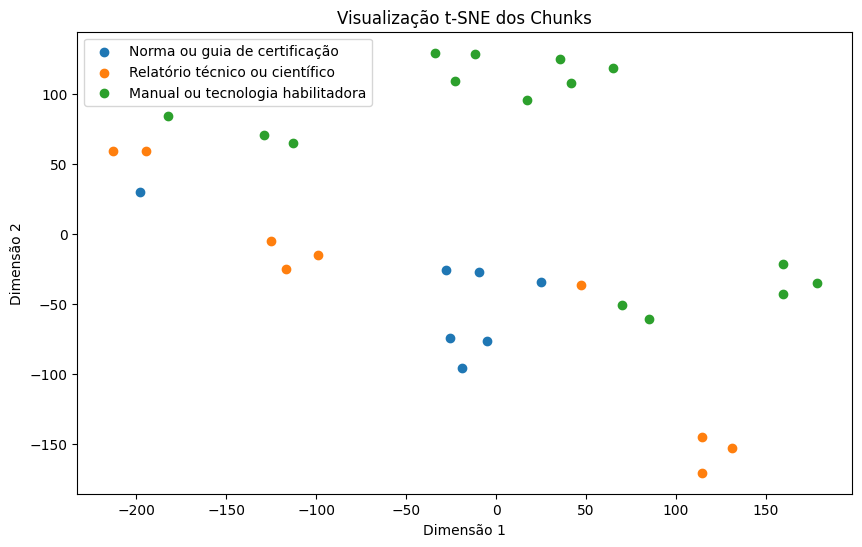

In [ ]:
perplexidade = min(5, len(df_chunks) - 1)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexidade
)

resultado_tsne = tsne.fit_transform(embeddings)

df_chunks["x"] = resultado_tsne[:, 0]

df_chunks["y"] = resultado_tsne[:, 1]

plt.figure(figsize=(10, 6))

for categoria in df_chunks["categoria"].unique():

    dados = df_chunks[df_chunks["categoria"] == categoria]

    plt.scatter(
        dados["x"],
        dados["y"],
        label=categoria
    )

plt.title("Visualização t-SNE dos Chunks")

plt.xlabel("Dimensão 1")

plt.ylabel("Dimensão 2")

plt.legend()

plt.show()

# Comparação entre RAG e LLM Puro

A comparação entre RAG e LLM puro mostra uma diferença importante. Um LLM puro responderia apenas com base em conhecimento geral, sem consultar os documentos do projeto e sem apresentar fontes rastreáveis. Já o sistema RAG desenvolvido neste notebook recupera trechos reais do corpus e mostra quais documentos foram utilizados em cada resposta.

Essa diferença é relevante porque o objetivo do desafio não é apenas gerar uma resposta plausível, mas sim construir um assistente técnico capaz de responder com base em documentos verificáveis. No contexto de edifícios verdes, eficiência energética, certificações ambientais, reúso de água e Net Zero, a rastreabilidade é essencial para reduzir alucinações e aumentar a confiança nas respostas.

# Relatório Crítico

O desenvolvimento do assistente técnico para projetos de edifícios eficientes quanto à água e energia demonstrou a importância do uso de RAG em problemas que exigem precisão, rastreabilidade e fundamentação documental. O tema de edifícios verdes envolve conceitos técnicos, certificações ambientais, estratégias de eficiência energética, sistemas fotovoltaicos, reúso de água, águas cinzas e captação de água da chuva. Embora modelos de linguagem generalistas sejam capazes de explicar esses assuntos em nível superficial, eles podem apresentar respostas incompletas ou sem vínculo claro com fontes específicas. Por isso, a construção de um corpus próprio foi essencial para aproximar o sistema de um assistente especializado.

Uma das principais dificuldades encontradas foi a organização do corpus. Mesmo com documentos voltados ao mesmo tema geral, os conteúdos possuem formatos e enfoques diferentes. Alguns materiais tratam de certificações ambientais, outros abordam energia, água ou tecnologias específicas. Essa diversidade é positiva para enriquecer a base de conhecimento, mas também exige uma etapa cuidadosa de metadados, limpeza e segmentação. A criação de categorias e subcategorias ajudou a organizar o conteúdo e permitiu compreender melhor a distribuição dos documentos usados.

A etapa de limpeza foi importante porque a extração de texto de PDFs pode gerar ruídos, como quebras de linha, espaços duplicados e fragmentos pouco úteis. Mesmo em documentos simples, a normalização melhora a qualidade dos chunks e reduz problemas na geração dos embeddings. A segmentação em chunks também foi decisiva, pois textos muito longos dificultam a recuperação de informações específicas, enquanto trechos muito curtos podem perder contexto. O uso de chunks com sobreposição buscou equilibrar esses dois pontos.

Na visualização t-SNE, os chunks foram projetados em duas dimensões para permitir uma análise visual dos agrupamentos. A distribuição observada ajuda a compreender como os documentos se aproximam semanticamente. Espera-se que conteúdos sobre água fiquem mais próximos entre si, assim como documentos relacionados a energia, eficiência energética e certificações ambientais. Mesmo que a visualização não seja perfeita, ela oferece uma evidência visual de que os embeddings capturam relações semânticas entre os textos.

Na avaliação com 10 perguntas, o sistema demonstrou capacidade de recuperar trechos relevantes do corpus e apresentar respostas associadas às fontes utilizadas. A proporção de sucesso depende diretamente da cobertura do corpus: perguntas sobre LEED, AQUA-HQE, Net Zero, energia fotovoltaica, reúso de água, águas cinzas, captação de água da chuva, PBE Edifica e PROCEL tendem a ser respondidas com maior qualidade porque esses temas estão representados nos documentos. Caso uma pergunta fuja do escopo, o sistema pode recuperar trechos menos adequados, indicando que a cobertura documental é um fator crítico para o desempenho do RAG.

A comparação entre RAG e LLM puro reforça a principal vantagem da arquitetura. O modelo sem contexto tende a produzir respostas genéricas, sem fonte e com maior risco de alucinação. Já o sistema com RAG utiliza documentos recuperados e apresenta maior rastreabilidade. Isso é especialmente importante em temas técnicos, nos quais uma resposta aparentemente correta pode ser inadequada se não estiver fundamentada em material confiável.

Como melhorias futuras, duas evoluções seriam prioritárias. A primeira seria ampliar o corpus com documentos oficiais mais extensos, normas técnicas, guias atualizados e relatórios científicos recentes. A segunda seria melhorar o mecanismo de chunking, respeitando seções, títulos e requisitos normativos para evitar cortes em pontos sensíveis. Além disso, seria interessante implementar filtros por categoria, permitindo ao usuário buscar apenas documentos de água, energia ou certificação ambiental. Com essas melhorias, o assistente poderia se tornar mais preciso, auditável e útil para apoiar decisões em projetos de edifícios sustentáveis.

# Conclusão

O notebook implementou um pipeline RAG funcional, contemplando construção do corpus, metadados, limpeza, segmentação, geração de embeddings, indexação vetorial com FAISS, recuperação semântica, avaliação com 10 perguntas, visualização t-SNE e relatório crítico.

A solução mostra que o uso de RAG melhora a rastreabilidade das respostas técnicas, reduz o risco de informações soltas e permite associar cada resposta aos documentos recuperados no corpus.